# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

**Penjelasan Singkat :**

untuk pengambilan proses clustering ini saya menggunakan dataset yang ada di kaggle, data yang saya pakai adalah data buatan untuk penjualan minuman. lalu tema yang saya ambil adalah **analisis penjualan minuman**.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from google.colab import files
from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


**Penjelasan Singkat :**

mengimport beberapa library yang di gunakan dalam pengembangan clustering ini, seperti numpy, pandas, seaborn dan lain sebagainya

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [34]:
sales_df = pd.read_csv("/content/drive/MyDrive/synthetic_beverage_sales_data.csv")
sales_df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23


**Penjelasan Singkat :**

Memuat dataset untuk melakukan clustering.

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

**Memahami Struktur Data**

In [35]:
sales_df.info()
sales_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Order_ID       object 
 1   Customer_ID    object 
 2   Customer_Type  object 
 3   Product        object 
 4   Category       object 
 5   Unit_Price     float64
 6   Quantity       int64  
 7   Discount       float64
 8   Total_Price    float64
 9   Region         object 
 10  Order_Date     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 755.3+ MB


,Unit_Price,Quantity,Discount,Total_Price
count,8.999910e+06,8.999910e+06,8.999910e+06,8.999910e+06
mean,5.818037e+00,2.313813e+01,2.972879e-02,1.307437e+02
std,1.470050e+01,2.689321e+01,4.479841e-02,5.096947e+02
min,3.200000e-01,1.000000e+00,0.000000e+00,3.000000e-01
25%,1.050000e+00,6.000000e+00,0.000000e+00,8.400000e+00
50%,1.750000e+00,1.100000e+01,0.000000e+00,2.114000e+01
75%,3.210000e+00,3.000000e+01,5.000000e-02,6.949000e+01
max,1.695300e+02,1.000000e+02,1.500000e-01,1.429530e+04


**Penjelasan Singkat :**

sebelum melakukan clustering saya memahami struktur datanya terlebih dahulu, disini data memiliki 8999910 baris dan 11 kolom, kemudian mempunyai 4 kolom dengan type numerik

**Menangani Data yang Hilang**

In [36]:
sales_df = sales_df.dropna()

**Penjelasan Singkat :**

saya menghapus data yang hilang di dalam dataset tersebut.

**Analisis Distribusi dan Korelasi**

         Unit_Price      Quantity      Discount   Total_Price
count  8.999910e+06  8.999910e+06  8.999910e+06  8.999910e+06
mean   5.818037e+00  2.313813e+01  2.972879e-02  1.307437e+02
std    1.470050e+01  2.689321e+01  4.479841e-02  5.096947e+02
min    3.200000e-01  1.000000e+00  0.000000e+00  3.000000e-01
25%    1.050000e+00  6.000000e+00  0.000000e+00  8.400000e+00
50%    1.750000e+00  1.100000e+01  0.000000e+00  2.114000e+01
75%    3.210000e+00  3.000000e+01  5.000000e-02  6.949000e+01
max    1.695300e+02  1.000000e+02  1.500000e-01  1.429530e+04


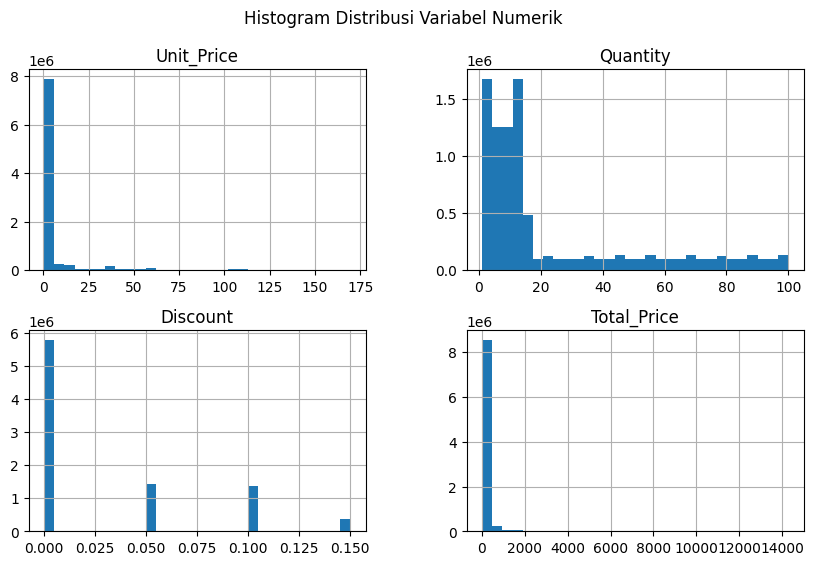

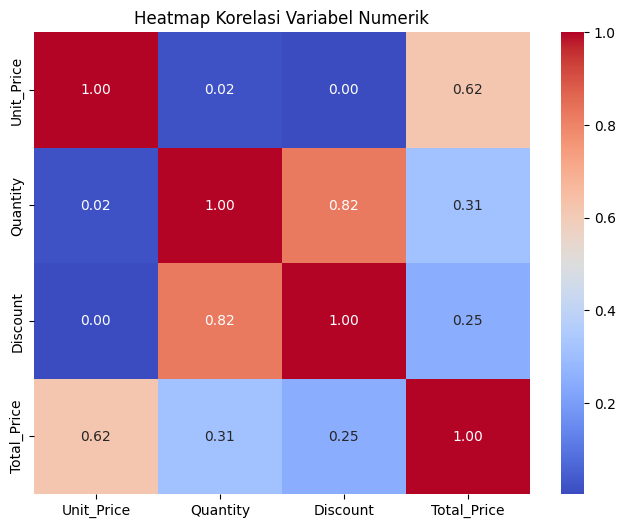

In [37]:
numerical_columns = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price']
print(sales_df[numerical_columns].describe())

sales_df[numerical_columns].hist(figsize=(10, 6), bins=30)
plt.suptitle("Histogram Distribusi Variabel Numerik")
plt.show()

correlation_matrix = sales_df[numerical_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(sales_df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Variabel Numerik")
plt.show()

**Penjelasan Singkat :**

untuk 4 kolom yang bertipe numerik tadi, saya analisis untuk mencari korelasi nya menggunakan visual heatmap.

saya mengambil korelasi yang >0.5 untuk pemilihan fitur disini terlihat ada :
- unit dengan total
- quantity dengan discount

**Visualisasi Data**

<ipython-input-38-964a3237a104>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Customer_Type', data=sales_df, palette='coolwarm')


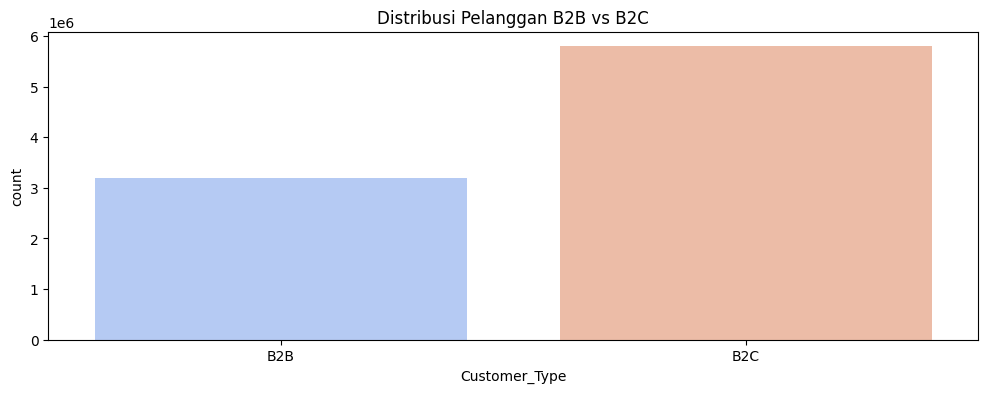

<ipython-input-38-964a3237a104>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=sales_df, palette='coolwarm')


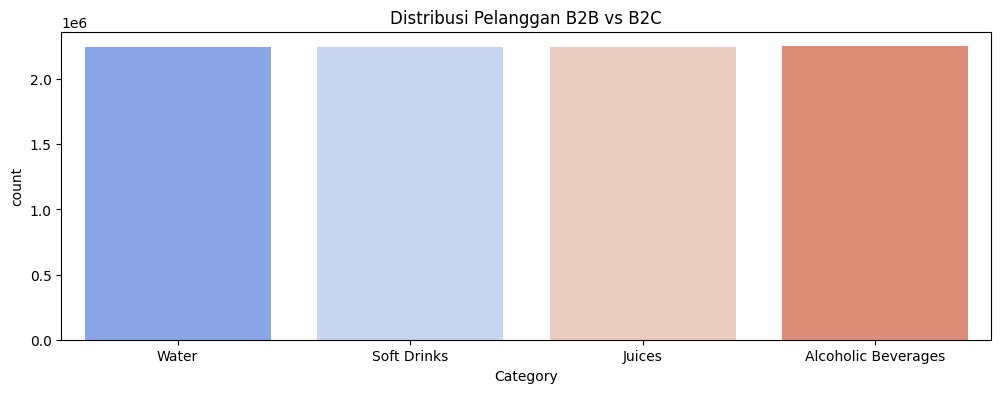

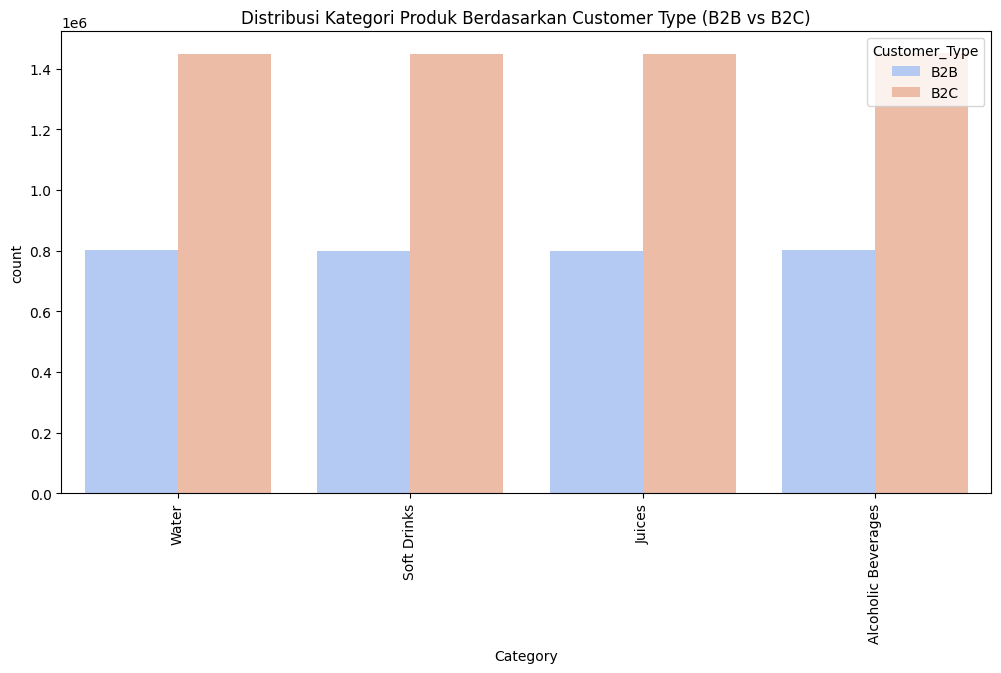

In [38]:
plt.figure(figsize=(12, 4))
sns.countplot(x='Customer_Type', data=sales_df, palette='coolwarm')
plt.title("Distribusi Pelanggan B2B vs B2C")
plt.show()

plt.figure(figsize=(12, 4))
sns.countplot(x='Category', data=sales_df, palette='coolwarm')
plt.title("Distribusi Pelanggan B2B vs B2C")
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='Category', hue='Customer_Type', data=sales_df, palette='coolwarm')
plt.xticks(rotation=90)
plt.title("Distribusi Kategori Produk Berdasarkan Customer Type (B2B vs B2C)")
plt.show()


**Penjelasan Singkat :**

saya melihat data untuk variabel kategorikal, saya coba kolom customer_type dan category, kemudian

dari 2 variabel tersebut saya lihat korelasi dari 2 data tersebut.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [41]:
sales_df.drop_duplicates(inplace=True)
print("Data duplicate sudah terhapus")

sales_df.drop(columns=['Order_ID', 'Customer_ID'], inplace=True)

print("Kolom Order_ID dan Customer_ID sudah dihapus.")

label_encoders = {}

categorical_features = ['Customer_Type', 'Category', 'Product', 'Region', 'Order_Date']

for col in categorical_features:
    le = LabelEncoder()
    sales_df[col] = le.fit_transform(sales_df[col])
    label_encoders[col] = le

print("Data categorical sudah di-encode.")


sales_df.head()

Data duplicate sudah terhapus
Kolom Order_ID dan Customer_ID sudah dihapus.
Data categorical sudah di-encode.


,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,0,42,3,1.66,53,0.10,79.18,0,963
1,0,9,3,1.56,90,0.10,126.36,0,963
2,0,38,2,1.17,73,0.05,81.14,0,963
3,0,29,1,3.22,59,0.10,170.98,0,963
4,0,12,3,0.87,35,0.10,27.40,0,963


**Penjelasan Singkat :**

setelah data di analisis lalu data saya proses dengan berbagai cara seperti :
- menghapus duplicate data
- mengencode data ketegorikal ke numerik
- menghapus kolom order_id dan custumer_id untuk memudahkan akurasi klustering karna unique

cara cara tersebut digunakan untuk melakukan clustering nantinya

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [43]:
sales_df = sales_df.iloc[:20000]

kmeans = KMeans(n_clusters=3, random_state=42)

sales_df['Cluster'] = kmeans.fit_predict(sales_df)

sales_df.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,0,42,3,1.66,53,0.10,79.18,0,963,0
1,0,9,3,1.56,90,0.10,126.36,0,963,0
2,0,38,2,1.17,73,0.05,81.14,0,963,0
3,0,29,1,3.22,59,0.10,170.98,0,963,0
4,0,12,3,0.87,35,0.10,27.40,0,963,0


**Penjelasan Singkat :**

kemudian saya membuat model clustering dengan algoritma KMeans, saya membuat 3 type cluster hanya dengan 20000 data awal saja (karna device)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

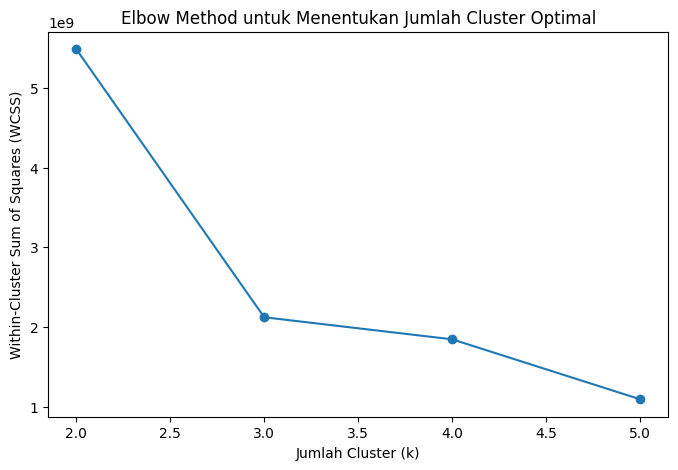

In [44]:
wcss = []
K = range(2, 6)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sales_df)
    wcss.append(kmeans.inertia_)

# Plot hasilnya
plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o', linestyle='-')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method untuk Menentukan Jumlah Cluster Optimal")
plt.show()


In [45]:
best_score = -1
best_k = 2

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(sales_df)
    score = silhouette_score(sales_df, cluster_labels)

    print(f"Cluster: {k}, Silhouette Score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nJumlah Cluster Optimal: {best_k} dengan Silhouette Score {best_score:.4f}")


Cluster: 2, Silhouette Score: 0.4819
Cluster: 3, Silhouette Score: 0.5303
Cluster: 4, Silhouette Score: 0.4499
Cluster: 5, Silhouette Score: 0.4703

Jumlah Cluster Optimal: 3 dengan Silhouette Score 0.5303


**Penjelasan Singkat :**

dari clustering yang sudah jadi, kemudian saya evaluasi menggunakan metode elbow dan Silhouette Score.

- dari metode elbow penggunaan 3 cluster sudah terbilang bagus terlihat dari titiknya yang menyerupai siku di titik tersebut.

- Pada pengujian Silhouette Score penggunaan 3 cluster juga lebih tinggi yang mendapatkan score 0.53

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [49]:
selected_features = ['Customer_Type', 'Category', 'Quantity', 'Unit_Price', 'Total_Price', 'Discount']

X_selected = sales_df[selected_features]


for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    sales_df['Cluster'] = kmeans.fit_predict(X_selected)

    score = silhouette_score(X_selected, sales_df['Cluster'])
    print(f"Cluster: {k}, Silhouette Score: {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

kmeans = KMeans(n_clusters=best_k, random_state=42)
sales_df['Cluster'] = kmeans.fit_predict(X_selected)

print(f"\nJumlah Cluster Optimal: {best_k} dengan Silhouette Score {best_score:.4f}")

Cluster: 2, Silhouette Score: 0.9552
Cluster: 3, Silhouette Score: 0.9311
Cluster: 4, Silhouette Score: 0.8848
Cluster: 5, Silhouette Score: 0.8824

Jumlah Cluster Optimal: 2 dengan Silhouette Score 0.9552


**Penjelasan Singkat :**


lalu saya melakukan seleksi fitur untuk membuat hasil cluster menjadi akurat, saya mengambil referensi korelasi data yang sebelumnya sudah saya coba.

- fitur yang di gunakan ada 6 yaitu : Customer_Type, Category, Quantity, Unit_Price, Total_Price, Discount.
- hasil Silhouette Score mencapai 0.9552 untuk penggunaan 2 cluster, ini cukup berbeda jika tidak di seleksi terlebih dahulu.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

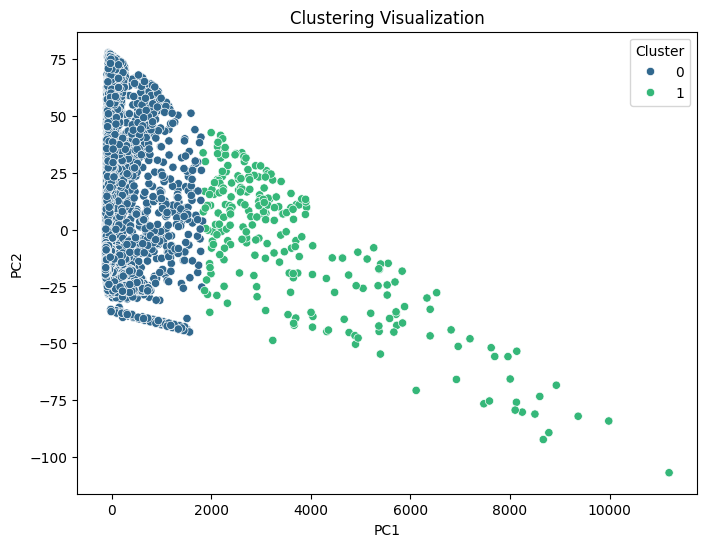

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

df_pca = sales_df.copy()
df_pca['PC1'] = X_pca[:, 0]
df_pca['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('Clustering Visualization')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()


**Penjelasan Singkat :**

kemudian untuk hasil clustering nya saya visualisasikan dengan metode 2D PCA, dapat dilihat cluster 0 jarak antar titik nya berdempet dan cluster 1 lebih menyebar. mungkin berbedaan signifikan pembelian satu dan lainnya untuk cluster 1

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [51]:
for col in categorical_features:
    sales_df[col] = label_encoders[col].inverse_transform(sales_df[col])

In [52]:
sales_df.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23,0
1,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23,0
2,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23,0
3,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23,0
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23,0


**Penjelasan Singkat :**

kemudian data kategorikal yang sebelumnya numerik untuk pelatihan di ubah kembali ke bentuk awal.

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [53]:
agg_numeric = sales_df.groupby('Cluster')[['Unit_Price', 'Quantity', 'Total_Price', 'Discount']].agg(['min', 'max', 'mean'])

agg_categorical = sales_df.groupby('Cluster')[['Customer_Type', 'Category']].agg(lambda x: x.mode()[0])

agg_result = pd.concat([agg_numeric, agg_categorical], axis=1)

print(agg_result)


         (Unit_Price, min)  (Unit_Price, max)  (Unit_Price, mean)  \
Cluster                                                             
0                     0.32             121.28            5.122819   
1                    24.07             137.36           57.291598   

         (Quantity, min)  (Quantity, max)  (Quantity, mean)  \
Cluster                                                       
0                      1              100         22.653472   
1                     26              100         76.475410   

         (Total_Price, min)  (Total_Price, max)  (Total_Price, mean)  \
Cluster                                                                
0                      0.39             1951.76            83.460722   
1                   1961.15            11325.33          3837.529262   

         (Discount, min)  (Discount, max)  (Discount, mean) Customer_Type  \
Cluster                                                                     
0                   0.00   

**Penjelasan Singkat :**

kemudian saya lakukan analisis untuk berbagai kolom untuk menarik kesimpulan dari hasil model cluster

- untuk data numerik dicari nilai min, max dan rata rata.
- untuk kategorikal di kategorikan lagi berdasarkan cluster

#### **Cluster 0: Konsumen Retail (B2C)**
- **Rata-rata Harga Unit:** $5.12

- **Rata-rata Jumlah Pembelian:** 22.65 unit  
- **Rata-rata Total Pembelian:** $83.46
- **Rata-rata Discount:** 0.02/2%
- **Kategori Produk Dominan:** Soft Drinks  
- **Tipe Pelanggan:** B2C (Business-to-Consumer)  

**Analisis:**  
Cluster ini mencakup pelanggan individu yang melakukan pembelian dalam jumlah yang lebih kecil dengan harga produk yang relatif rendah, maka dari itu diskon rata rata pada cluster ini hanya 2%. Mereka cenderung membeli minuman ringan (Soft Drinks) dalam skala kecil hingga menengah. Konsumen dalam cluster ini kemungkinan besar adalah pelanggan ritel yang sering melakukan pembelian tetapi dalam jumlah yang lebih sedikit dibandingkan dengan pelanggan grosir.

---

#### **Cluster 1: Pembeli Grosir (B2B)**
- **Rata-rata Harga Unit:** $57.29  
- **Rata-rata Jumlah Pembelian:** 76.47 unit

- **Rata-rata Total Pembelian:** $3,837.53
- **Rata-rata Discount:** 0.10/10%
- **Kategori Produk Dominan:** Alcoholic Beverages  
- **Tipe Pelanggan:** B2B (Business-to-Business)  

**Analisis:**  
Cluster ini terdiri dari pembeli dalam jumlah besar dengan harga produk yang jauh lebih tinggi, tak heran untuk discount 10% untuk rata rata nya. Mereka lebih cenderung membeli minuman beralkohol dalam jumlah besar, yang menunjukkan bahwa pelanggan dalam cluster ini bisa jadi adalah distributor, restoran, atau toko minuman. Dengan total pembelian yang jauh lebih tinggi dibandingkan Cluster 0, pelanggan ini kemungkinan besar melakukan pembelian dalam jumlah grosir untuk dijual kembali atau digunakan dalam bisnis mereka.  

---

**Kesimpulan:**  
- **Cluster 0** lebih didominasi oleh pelanggan individu (B2C) dengan pembelian dalam jumlah kecil dan harga rendah.  
- **Cluster 1** terdiri dari pelanggan grosir (B2B) dengan pembelian dalam jumlah besar dan harga tinggi.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [56]:
sales_df.to_csv('cluster_sales.csv', index=True)
sales_df.head()

,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
0,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23,0
1,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23,0
2,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23,0
3,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23,0
4,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23,0
